# Hierarchical RL: Options Framework

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand hierarchical RL concepts
- Implement the options framework (initiation set, internal policy, termination condition)
- Build temporally extended actions on a standard Gymnasium environment
- **Measure** what options actually buy over primitive actions — learning speed and number of
  decisions — instead of taking the claim on trust

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 2, lesson 01 "02. Knowledge Representation" — you represented a domain with named concepts and relations rather than raw facts; an option applies that move to *actions*, letting one named skill stand in for a long run of primitive steps.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Experimenting with hierarchical RL using options framework

---

## Introduction

**Hierarchical RL** uses temporal abstraction (options) to solve tasks by breaking them into
subtasks. This notebook runs two agents on the *same* environment — one choosing primitive
actions, one choosing options — and compares what they cost to train.

## Lesson Brief

This lesson introduces hierarchical RL through the idea of **options**, or reusable multi-step behaviors.

Students will see how a controller can make higher-level decisions instead of choosing every primitive action one by one.

Why this matters: hierarchical structure is useful when tasks are long, repetitive, or naturally broken into subgoals.

This lesson helps students think about abstraction in RL.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: the Atari game DQN scored zero on

Mnih et al.'s DQN (*Nature* **518**, 529–533, 2015) reached more than 75% of a professional human
games tester's score on 29 of the 49 Atari games — the paper's own bar for "comparable to" a human.
On **Montezuma's Revenge** it scored **0**.

The game explains why. To earn any reward at all the player must climb down a ladder, cross a room,
jump a gap, avoid a skull, reach a key, and only then — after a long, specific sequence — receive
+100. Random exploration essentially never completes that sequence, so there is nothing to learn
from. The paper names it as the open problem: "games demanding more temporally extended planning
strategies still constitute a major challenge for all existing agents including DQN (for example,
Montezuma's Revenge)".

Kulkarni, Narasimhan, Saeedi and Tenenbaum answered it with **hierarchy** ("Hierarchical Deep
Reinforcement Learning: Integrating Temporal Abstraction and Intrinsic Motivation", 2016). Their
h-DQN has two levels: a *meta-controller* that picks a **subgoal** ("get to the ladder", "get the
key"), and a *controller* that learns to reach whichever subgoal it was given. The meta-controller
then plans over a handful of subgoals instead of over tens of thousands of joystick moves. They state
the baseline plainly: "the basic DQN achieves a score of 0 while even the best performing system,
Gorila DQN, manages only 4.16 on average" — and h-DQN made real progress where flat agents made none.

**What goes wrong without this.** A flat agent must stumble onto the entire correct sequence by
chance before it learns anything. With options, one decision commits to several steps, so the search
happens over plans rather than over keystrokes. The run below measures exactly that on a map small
enough to see.


## Recommended YouTube Video

To reinforce this lesson, watch **Universitat Pompeu Fabra - Barcelona - "RLSS 2023: Hierarchical Reinforcement Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=dooSrAH3o14)

Why this pick:
- Clear academic English and a theory-first explanation of hierarchy.
- Gives students a stronger overview of subtasks, abstraction, and long-horizon decomposition.
- Better fit for options-style thinking than a generic deep RL tutorial.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Hierarchy: solving with smaller sub-tasks.
- Option: a multi-step higher-level action.
- Subgoal: an intermediate target.
- Temporal abstraction: thinking beyond one step.
- High-level controller: chooses which option to run.

### Quick Check
- Why can hierarchy simplify a long task?
- What is the difference between an option and a primitive action?
- How do subgoals help sparse rewards?
- Why does temporal abstraction reduce decision burden?

### Common Mistakes
- Thinking hierarchy only adds complexity.
- Confusing options with ordinary actions.
- Missing the value of subgoals.
- Forgetting that the controller chooses options, while the option handles several primitive steps internally.


## Options Are Not Just Fancy Actions

A common student confusion is to hear the word option and think it is simply another action label.

### Primitive action

A primitive action is one immediate move, such as:

- step left
- step right
- open gripper

### Option

An option is a **temporally extended behavior**:

- it can start in some states
- it follows its own internal policy
- it stops when its termination condition is met

### Why this matters

The high-level controller does not micromanage every single step.
It chooses a reusable behavior, and that behavior runs for multiple time steps.

That is the real source of temporal abstraction.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# WHAT: set up the environment both agents in this notebook will learn on.
# WHY: a claim about hierarchy only means something if both the flat agent and the hierarchical
#      agent face the SAME task. We use Gymnasium's FrozenLake-v1, a published benchmark, with
#      is_slippery=False so that an option's behaviour is predictable - the lesson here is
#      temporal abstraction, not stochastic dynamics.

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
N_STATES = env.observation_space.n
N_PRIMITIVE_ACTIONS = env.action_space.n
TILES = env.unwrapped.desc.astype(str).ravel()      # 'S' start, 'F' frozen, 'H' hole, 'G' goal
GAMMA = 0.95

# Gymnasium's action ids and the row/column each one moves by.
ACTION_NAMES = ["left", "down", "right", "up"]
ACTION_DELTA = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}

print("✅ Libraries imported!")
print("\nHierarchical RL: Options Framework")
print("=" * 60)
print(f"Environment : FrozenLake-v1 4x4, not slippery (Gymnasium {gym.__version__})")
print(f"States      : {N_STATES}   Primitive actions: {N_PRIMITIVE_ACTIONS} -> {', '.join(ACTION_NAMES)}")
print("Reward      : +1 for reaching the goal, 0 otherwise; falling in a hole ends the episode")
print("Map:")
for row in range(4):
    print("   " + " ".join(TILES[row * 4:(row + 1) * 4]))

print("\nOptions Framework:")
print("  - Option: temporally extended action (initiation set + internal policy + termination)")
print("  - Initiation set: states where the option is allowed to start")
print("  - Policy: what the option does while it is running")
print("  - Termination: the condition that hands control back to the controller")


✅ Libraries imported!

Hierarchical RL: Options Framework
Environment : FrozenLake-v1 4x4, not slippery (Gymnasium 1.3.0)
States      : 16   Primitive actions: 4 -> left, down, right, up
Reward      : +1 for reaching the goal, 0 otherwise; falling in a hole ends the episode
Map:
   S F F F
   F H F H
   F F F H
   H F F G

Options Framework:
  - Option: temporally extended action (initiation set + internal policy + termination)
  - Initiation set: states where the option is allowed to start
  - Policy: what the option does while it is running
  - Termination: the condition that hands control back to the controller


## Worked Example: Why Options Help in Long Tasks

Imagine a delivery robot moving through a building.

At the primitive-action level, the robot chooses one step at a time. That works, but the
controller must reason over many small actions before anything meaningful happens.

Hierarchical RL introduces **options** such as `go_to_hallway` or `approach_goal`. Each option
is a small policy that lasts for several time steps, and the high-level controller chooses
**which option to run**, not every single movement step.

### The options we will actually build

On FrozenLake, the equivalent of "walk down the hallway" is a **safe walk**:

> `safe_walk(direction)` — keep moving in one direction for **up to 3 steps**, and stop early if
> the next tile would be a wall or a hole, or if the episode ends.

That gives four options (`left`, `down`, `right`, `up`), each with all three ingredients the
options framework requires:

| Ingredient | In `safe_walk(direction)` |
|---|---|
| Initiation set | any non-terminal tile where the first move is not blocked |
| Internal policy | "keep going in `direction`" |
| Termination | 3 steps taken, a wall or hole ahead, or the episode ended |

**These options are hand-designed, not learned.** That is the original setting in Sutton, Precup
& Singh (1999) — options are *given*, and the agent learns how to *sequence* them. Learning the
options themselves (option-critic) is a later topic, and this notebook does not attempt it.

### The one change to the Q-learning update

When an option runs for `k` steps, the controller's update has to discount the bootstrap by the
option's real duration:

`Q(s, o) ← Q(s, o) + α [ R_k + γ^k · max_o' Q(s', o') − Q(s, o) ]`

where `R_k` is the discounted reward collected *during* the option. That is **SMDP Q-learning** —
the same rule as ordinary Q-learning, with `γ` replaced by `γ^k`.

### Step Guide

**What this cell does:** Trains two agents on the same map — a **flat** Q-learner over the 4
primitive actions, and a **hierarchical** SMDP Q-learner over the 4 options — then compares how
fast each one learned and how many decisions each one makes.

**How to read it (weak Python OK):** Read `safe_walk` first — it is the option. Then notice that
the two training loops are nearly identical; the only real difference is `disc` (that is `γ^k`)
in the hierarchical update.

**What to expect in the output:** a training comparison table (episodes to reach a 90% success
rate, environment steps spent getting there, decisions per episode at the end), the greedy
option plan written out as a sequence, and a figure with two learning curves.

**If you feel lost:** read only the "episodes to reach 90% success" row. Both agents solve the
map; the question the whole notebook asks is *how expensive it was to get there*.

Two agents, one map, one metric each
                                        flat (primitives)      options
  success rate, last 100 episodes                   0.97         1.00
  episodes to reach 90% success                      204           26
  environment steps spent getting there             1465          974
  decisions per episode (last 100)                   6.2          4.2
  primitive steps per episode (last 100)             6.2          6.3

Greedy plan learned by the controller: down x2 -> right x2 -> down x1 -> right x1
Reached the goal tile: True
That is 4 controller decisions covering 6.3 primitive steps on average.

What the table says:
  - Options reached a reliable policy in 26 episodes vs 204 for the flat agent (7.8x fewer).
  - Both agents end up solving the map. Hierarchy did not raise the ceiling; it changed
    the cost of getting there, because each decision commits to several steps at once.
  - The options were hand-designed. That help is real, and it is also

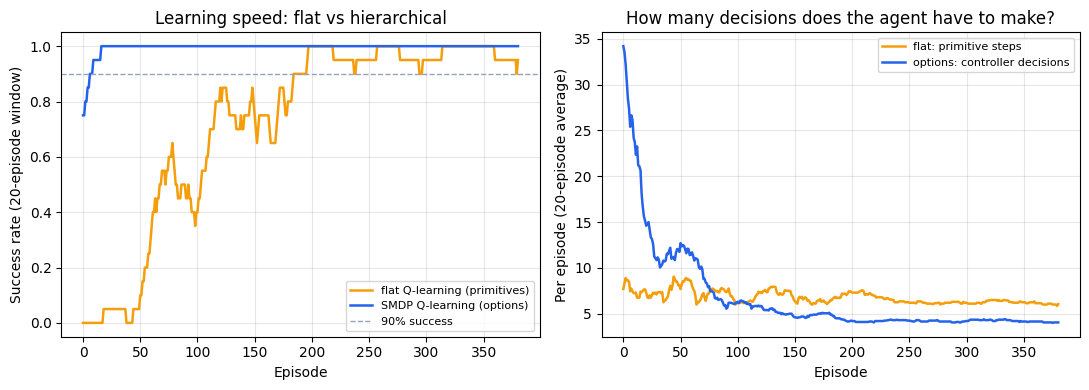

In [2]:
# WHAT: train a flat Q-learner over primitive actions and an SMDP Q-learner over options,
#       on the same map, and measure the difference.
# WHY: "hierarchy helps" is a claim. Two agents, one environment, one metric each - that is
#      what turns it into a measurement students can check.

MAX_OPTION_STEPS = 3          # how long one option may run before handing control back
EPISODES = 400
ALPHA = 0.5
EPSILON_DECAY = 0.99
STEP_CAP = 60                 # safety cap so a wandering agent cannot loop forever


def greedy_action(rng, q_row):
    """Argmax with random tie-breaking, so an all-zero table does not always pick action 0."""
    best = np.flatnonzero(q_row == q_row.max())
    return int(rng.choice(best))


def safe_walk(direction, state):
    """Run one option: repeat `direction` for up to MAX_OPTION_STEPS steps.

    Terminates early on a wall, on a hole ahead, or when the episode ends. Returns the state
    the controller wakes up in, the discounted reward collected inside the option, gamma**k
    for the k steps actually taken, k itself, and whether the episode finished.
    """
    discounted_reward, discount, steps_taken, finished = 0.0, 1.0, 0, False
    current = state
    for _ in range(MAX_OPTION_STEPS):
        row, col = divmod(current, 4)
        d_row, d_col = ACTION_DELTA[direction]
        next_row, next_col = row + d_row, col + d_col
        if not (0 <= next_row < 4 and 0 <= next_col < 4):
            break                                   # wall ahead: terminate the option
        if TILES[next_row * 4 + next_col] == "H":
            break                                   # hole ahead: terminate the option
        current, reward, terminated, truncated, _ = env.step(direction)
        discounted_reward += discount * reward
        discount *= GAMMA
        steps_taken += 1
        if terminated or truncated:
            finished = True
            break
    return current, discounted_reward, discount, steps_taken, finished


def train_flat(episodes=EPISODES, seed=0):
    """Ordinary Q-learning over the 4 primitive actions."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_PRIMITIVE_ACTIONS))
    epsilon = 1.0
    successes, steps_per_episode = [], []
    for _ in range(episodes):
        state, _ = env.reset()
        steps, won = 0, 0
        for _ in range(STEP_CAP):
            action = int(rng.integers(N_PRIMITIVE_ACTIONS)) if rng.random() < epsilon else greedy_action(rng, Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            # Ordinary Q-learning: one step, so the bootstrap is discounted by gamma^1.
            Q[state, action] += ALPHA * (reward + GAMMA * Q[next_state].max() - Q[state, action])
            state = next_state
            steps += 1
            if terminated or truncated:
                won = int(reward > 0)
                break
        epsilon = max(epsilon * EPSILON_DECAY, 0.05)
        successes.append(won)
        steps_per_episode.append(steps)
    return Q, np.array(successes), np.array(steps_per_episode)


def train_with_options(episodes=EPISODES, seed=0):
    """SMDP Q-learning over the 4 safe-walk options."""
    rng = np.random.default_rng(seed)
    n_options = 4
    Q = np.zeros((N_STATES, n_options))
    epsilon = 1.0
    successes, decisions_per_episode, steps_per_episode = [], [], []
    for _ in range(episodes):
        state, _ = env.reset()
        decisions, steps, won = 0, 0, 0
        for _ in range(STEP_CAP):
            option = int(rng.integers(n_options)) if rng.random() < epsilon else greedy_action(rng, Q[state])
            next_state, option_reward, discount, k, finished = safe_walk(option, state)
            decisions += 1
            steps += k
            if k == 0:
                # The option could not even start here (wall or hole immediately ahead).
                # Charge a small penalty so the controller learns not to pick it in this state.
                Q[state, option] += ALPHA * (-0.05 - Q[state, option])
                continue
            # SMDP update: gamma**k, because the option consumed k real time steps.
            Q[state, option] += ALPHA * (option_reward + discount * Q[next_state].max() - Q[state, option])
            state = next_state
            if finished:
                won = int(option_reward > 0)
                break
        epsilon = max(epsilon * EPSILON_DECAY, 0.05)
        successes.append(won)
        decisions_per_episode.append(decisions)
        steps_per_episode.append(steps)
    return Q, np.array(successes), np.array(decisions_per_episode), np.array(steps_per_episode)


Q_flat, flat_success, flat_steps = train_flat()
Q_options, option_success, option_decisions, option_steps = train_with_options()


def episodes_to_reach(successes, window=20, threshold=0.9):
    """First episode at which the success rate over a 20-episode window reaches `threshold`."""
    rolling = np.convolve(successes, np.ones(window) / window, mode="valid")
    return int(np.argmax(rolling >= threshold) + window) if rolling.max() >= threshold else None


flat_reached = episodes_to_reach(flat_success)
option_reached = episodes_to_reach(option_success)
flat_env_steps = int(flat_steps[:flat_reached].sum()) if flat_reached else None
option_env_steps = int(option_steps[:option_reached].sum()) if option_reached else None

print("Two agents, one map, one metric each")
print("=" * 68)
print(f"  {'':<38}{'flat (primitives)':>16}{'options':>13}")
print(f"  {'success rate, last 100 episodes':<38}{flat_success[-100:].mean():>16.2f}{option_success[-100:].mean():>13.2f}")
print(f"  {'episodes to reach 90% success':<38}{str(flat_reached):>16}{str(option_reached):>13}")
print(f"  {'environment steps spent getting there':<38}{str(flat_env_steps):>16}{str(option_env_steps):>13}")
print(f"  {'decisions per episode (last 100)':<38}{flat_steps[-100:].mean():>16.1f}{option_decisions[-100:].mean():>13.1f}")
print(f"  {'primitive steps per episode (last 100)':<38}{flat_steps[-100:].mean():>16.1f}{option_steps[-100:].mean():>13.1f}")

# What plan did the controller actually learn? Write it out as a sequence of options.
state, _ = env.reset()
plan = []
rng_demo = np.random.default_rng(0)
for _ in range(12):
    option = greedy_action(rng_demo, Q_options[state])
    state, option_reward, _discount, k, finished = safe_walk(option, state)
    if k == 0:
        plan.append(f"{ACTION_NAMES[option]}(blocked)")
        break
    plan.append(f"{ACTION_NAMES[option]} x{k}")
    if finished:
        break
print(f"\nGreedy plan learned by the controller: {' -> '.join(plan)}")
print(f"Reached the goal tile: {TILES[state] == 'G'}")
print(f"That is {len(plan)} controller decisions covering "
      f"{option_steps[-100:].mean():.1f} primitive steps on average.")

# Conclusions written FROM the measurements above, so they cannot go stale.
print("\nWhat the table says:")
if flat_reached and option_reached and option_reached < flat_reached:
    print(f"  - Options reached a reliable policy in {option_reached} episodes vs {flat_reached} "
          f"for the flat agent ({flat_reached / option_reached:.1f}x fewer).")
elif flat_reached and option_reached:
    print(f"  - The flat agent got there first ({flat_reached} vs {option_reached} episodes) - "
          "report what you measured, not what you expected.")
else:
    print("  - At least one agent never reached 90% success within the episode budget.")
print("  - Both agents end up solving the map. Hierarchy did not raise the ceiling; it changed")
print("    the cost of getting there, because each decision commits to several steps at once.")
print("  - The options were hand-designed. That help is real, and it is also the honest catch:")
print("    a badly chosen option set can make learning slower, not faster.")

# ── Figure: learning curves ────────────────────────────────────────────────────
window = 20
flat_curve = np.convolve(flat_success, np.ones(window) / window, mode="valid")
option_curve = np.convolve(option_success, np.ones(window) / window, mode="valid")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(flat_curve, label="flat Q-learning (primitives)", color="#f59e0b", linewidth=1.8)
axes[0].plot(option_curve, label="SMDP Q-learning (options)", color="#2563eb", linewidth=1.8)
axes[0].axhline(0.9, color="#94a3b8", linestyle="--", linewidth=1, label="90% success")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel(f"Success rate ({window}-episode window)")
axes[0].set_title("Learning speed: flat vs hierarchical")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.convolve(flat_steps, np.ones(window) / window, mode="valid"),
             label="flat: primitive steps", color="#f59e0b", linewidth=1.8)
axes[1].plot(np.convolve(option_decisions, np.ones(window) / window, mode="valid"),
             label="options: controller decisions", color="#2563eb", linewidth=1.8)
axes[1].set_xlabel("Episode")
axes[1].set_ylabel(f"Per episode ({window}-episode average)")
axes[1].set_title("How many decisions does the agent have to make?")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 👁️ Read the figure

- **Left panel — how fast each agent became reliable.** Both agents learn the same 4x4 map. The
  y-axis is the fraction of the last 20 episodes that reached the goal; the grey dashed line marks
  90%. The blue options agent is above that line within a few dozen episodes. The orange flat
  agent spends roughly its first 50 episodes at zero and only crosses 90% around episode 200. The
  exact episode counts, and the environment steps each one spent getting there, are in the table
  printed above.
- **Both curves finish at the top.** Hierarchy did **not** raise the ceiling — the flat agent
  solves this map perfectly well in the end. It changed how long the climb took.
- **Right panel counts two different things, on purpose — read the legend before the lines.**
  Orange is *primitive steps* the flat agent took per episode; blue is *controller decisions* the
  options agent had to make. They are not the same unit, and that is the point: one option
  decision commits to up to three primitive moves, so the hierarchical agent reaches the goal
  while choosing far fewer times.
- **The blue line starts above 30 and falls hard.** Early on the controller picks options at
  random and many of them are blocked immediately by a wall or a hole, so it burns decisions
  achieving nothing. Learning which option is even *legal* where is part of what it learns.

**What it proves:** temporal abstraction buys sample efficiency, not capability. Read that
alongside the honest catch printed under the table — these four options were hand-designed by us,
and a badly chosen option set would have pushed the blue curve to the right of the orange one.

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S., Precup, D. & Singh, S. (1999). *Between MDPs and Semi-MDPs: A Framework for Temporal Abstraction in Reinforcement Learning* (the options framework). Artificial Intelligence, 112, 181-211.
2. Bacon, P.-L., Harb, J. & Precup, D. (2017). *The Option-Critic Architecture*. AAAI. <https://arxiv.org/abs/1609.05140>
3. Murphy, K. (2024). *Reinforcement Learning: An Overview*. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>
4. Zhou, X., Zhang, S., Zhao, Y. et al. (2026). *GUI vs. CLI: Execution Bottlenecks in Screen-Only and Skill-Mediated Computer-Use Agents* — options reappear as skill interfaces, and their coverage is the binding limit. arXiv:2606.24551. <https://arxiv.org/abs/2606.24551>
5. Lu, Z., Yao, Z., Wu, J. et al. (2026). *SKILL0: In-Context Agentic Reinforcement Learning for Skill Internalization* — learning reusable multi-step procedures instead of retrieving them at run time. arXiv:2604.02268. <https://arxiv.org/abs/2604.02268>
"""))

## 📚 References

1. Sutton, R. S., Precup, D. & Singh, S. (1999). *Between MDPs and Semi-MDPs: A Framework for Temporal Abstraction in Reinforcement Learning* (the options framework). Artificial Intelligence, 112, 181-211.
2. Bacon, P.-L., Harb, J. & Precup, D. (2017). *The Option-Critic Architecture*. AAAI. <https://arxiv.org/abs/1609.05140>
3. Murphy, K. (2024). *Reinforcement Learning: An Overview*. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>
4. Zhou, X., Zhang, S., Zhao, Y. et al. (2026). *GUI vs. CLI: Execution Bottlenecks in Screen-Only and Skill-Mediated Computer-Use Agents* — options reappear as skill interfaces, and their coverage is the binding limit. arXiv:2606.24551. <https://arxiv.org/abs/2606.24551>
5. Lu, Z., Yao, Z., Wu, J. et al. (2026). *SKILL0: In-Context Agentic Reinforcement Learning for Skill Internalization* — learning reusable multi-step procedures instead of retrieving them at run time. arXiv:2604.02268. <https://arxiv.org/abs/2604.02268>


## 💬 Discuss

The measured comparison, same map, same metric:

| | flat (primitives) | options |
|---|---|---|
| success rate, last 100 episodes | 0.97 | 1.00 |
| episodes to reach 90% success | **204** | **26** |
| environment steps to get there | 1465 | 974 |
| decisions per episode | 6.2 | 4.2 |
| primitive steps per episode | 6.2 | 6.3 |

Argue these out.

1. Options reached 90% success **7.8× faster in episodes** but only **1.5× faster in environment
   steps** (1465 vs 974). Which of those two numbers is the honest headline? Name a setting where the
   episode count is what costs money, and one where the step count is.
2. Both agents end up solving the map (0.97 and 1.00), and both take about 6.3 primitive steps per
   episode at the end. So hierarchy changed nothing about the final answer. The notebook says it
   "changed the cost of getting there". When is that worth building a two-level system for, and when
   is it a complication you should refuse?
3. The options here were **hand-designed** — the notebook is explicit about it, and calls it the
   honest catch. Someone already knew the map. Write down what a *bad* option set would look like on
   this map, and predict what the table above would show if you used it. Then answer the real
   question: where would the options come from in a problem you have not solved yet?


## Summary

This notebook introduced the options framework and then **tested** it:

- primitive actions control the environment one step at a time
- **options** are reusable multi-step behaviours with an initiation set, an internal policy and
  a termination condition
- the high-level controller selects options, not individual moves
- the only change to Q-learning is `γ^k` in place of `γ` — **SMDP Q-learning**

### What the run above actually showed

Two agents learned the same FrozenLake map. Read your own output, not this sentence: the table
reports how many episodes each needed to reach a 90% success rate, how many environment steps
that cost, and how many decisions each makes per episode once trained.

The honest reading is that **both agents solve the map**. Hierarchy did not make the task
solvable — it changed how expensive learning was, because one decision commits to several steps.

### The catch worth remembering

The four `safe_walk` options were **written by hand**, using knowledge of where the holes are.
That is a real advantage handed to the hierarchical agent, and it is why option *discovery* is
an open research problem: options that do not match the task can make learning slower, not
faster.

### Why this matters

Hierarchical structure becomes useful when tasks are long, repetitive, or have natural subgoals
such as hallways, rooms, checkpoints or pickup locations.

## ⚠️ Where this breaks

**The assumption that has to hold:** somebody can name useful subgoals. Hierarchy is a way of
injecting knowledge about the problem structure, and it helps exactly as much as that knowledge is
correct.

- **Hand-designed options are hand-designed knowledge.** The 7.8× speed-up above came from a human
  who already knew the map. Strip that away and you have the option-discovery problem, which is open:
  learning useful temporal abstractions automatically is still a research topic, not a technique you
  can rely on in a project plan.
- **A bad option set makes learning slower, not faster.** An option that commits the agent to six
  steps in a direction it should not go is worse than six free choices. The notebook says this
  outright, and it is the standard failure mode: hierarchy narrows the search, and a narrowed search
  can exclude the answer.
- **Hierarchy does not raise the ceiling.** Both agents here reach ~1.00. Options bought sample
  efficiency, not capability. If your flat agent is failing because the *reward is wrong* or the
  *state is missing information*, hierarchy will not save it — it will get to the wrong answer faster.
- **Two levels means two sets of hyperparameters and a harder debugging story.** When the system
  fails, you now have to work out whether the controller cannot reach subgoals or the meta-controller
  is choosing bad ones.
- **Cheaper alternative:** before building a hierarchy, try shaping the *task*: shorter episodes,
  easier start states, a curriculum from easy maps to hard ones. All three attack the same sparse-
  reward problem with less machinery. And if you can already write the subgoal sequence down — as you
  could on this map — a scripted controller calling a learned low-level policy is simpler than a
  learned meta-controller, and easier to certify.


## Closing Takeaway

**Teaching takeaway:** Hierarchical RL breaks long tasks into reusable sub-skills so the agent can reason at more than one level of abstraction — and the payoff shows up as *learning cost*, not as a higher score ceiling.

**If students remember one idea:** An option is a policy with a start condition and a stop condition. The controller picks options; the option picks the individual moves.

**Quick check before moving on:**
- Can you explain how an option differs from a single primitive action?
- Why does the SMDP update use `γ^k` instead of `γ`?
- The options here were hand-written. What would break if they were chosen badly?

**Bridge to the next step:** The next lesson changes perspective again by learning a model of the world and planning with it.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.

## 🔭 State of the field (2026)

Temporal abstraction did not stay inside RL. In 2026 the same idea is a main design axis in agent systems under
a different name — **skills**: a named, reusable procedure with a precondition, a body and a stopping rule,
written as a script or a documented tool. A controlled 2026 comparison of computer-use agents reports that
agents acting through such a skill interface are limited by the *coverage and scalability of that interface*,
while agents acting on raw screen pixels are limited by reliable grounded interaction over long workflows
(Zhou et al. 2026) — the option-design trade-off of this lesson, measured on a different substrate. Learning
those procedures rather than being handed them, and folding them into the policy so they need not be retrieved
at run time, is the current form of the option-discovery problem (Lu et al. 2026).

That is why this framework is worth your time rather than a historical note. Initiation set, internal policy and
termination condition are the three things you must specify for *any* skill, in RL or in an agent harness, and
the `γ^k` correction is the reason a decision that commits to several steps cannot be credited like a
single-step one. The lesson's honest catch travels with it: the 2026 work reports the same result you measured,
that a skill set which does not match the task narrows the search past the answer.

- Zhou, X., Zhang, S., Zhao, Y. et al. (2026). *GUI vs. CLI: Execution Bottlenecks in Screen-Only and Skill-Mediated Computer-Use Agents*. arXiv:2606.24551. <https://arxiv.org/abs/2606.24551>
- Lu, Z., Yao, Z., Wu, J. et al. (2026). *SKILL0: In-Context Agentic Reinforcement Learning for Skill Internalization*. arXiv:2604.02268. <https://arxiv.org/abs/2604.02268>

*Context, not curriculum. The examinable content of this lesson is unchanged; this box says where the field went next.*

## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=6 | term=True | trunc=False


objc[67355]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fe28138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1103249c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67355]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fe28188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110324a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67355]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fe27c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110324a68). T

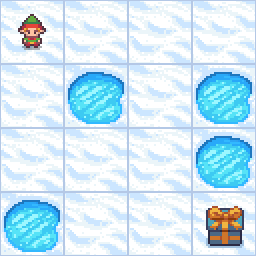

In [4]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
